In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam, ClippedAdam
from pyro.infer.autoguide import AutoMultivariateNormal, AutoDiagonalNormal

c:\Users\Maria\anaconda3\envs\mbml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Download datasets

## Train

In [2]:
df_original=pd.read_csv("data/train.csv")
df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Choose relevant columns

In [3]:
df_train = df_original[["DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT"]]
df_train = df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

df_train.to_csv("data/train_filter.csv", index=False)

print(f"Number of observations: {len(df_train)}")
print(df_train.isna().sum())
df_train.head()

Number of observations: 4542343
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
DEPARTING_AIRPORT     0
dtype: int64


,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT
0,0,26,American Airlines Inc.,0.00,4.25,Douglas Municipal
1,0,63,SkyWest Airlines Inc.,0.00,11.41,Stapleton International
2,0,3,American Eagle Airlines Inc.,0.00,0.45,Adams Field
3,0,14,Southwest Airlines Co.,0.00,8.05,San Diego International Lindbergh Fl
4,0,85,American Eagle Airlines Inc.,0.01,10.51,Chicago O'Hare International


In [4]:
# Create weather data and standardize <br>
# Do log transformation on rain data since most values are zero

# weather_scaler = StandardScaler()
# df_train["PRCP_LOG"] = np.log1p(df_train["PRCP"])  
# X_weather_train = weather_scaler.fit_transform(df_train[["PRCP_LOG", "WIND"]])

One hot encode carrier, we are not using airport yet

In [5]:
# one hot encode airport
# airport_dummies = pd.get_dummies(df_train["DEPARTING_AIRPORT"], prefix="airport")
# airport_columns = airport_dummies.columns.tolist()

# one hot encode carrier
carrier_dummies = pd.get_dummies(df_train["CARRIER_NAME"], prefix="carrier")
carrier_columns = carrier_dummies.columns.tolist()

# df_train = pd.concat([df_train, airport_dummies, carrier_dummies], axis=1)
df_train = pd.concat([df_train, carrier_dummies], axis=1)

In [6]:
# Create stress data and standardize

# X_stress_raw = df_train[["AIRPORT_SIZE_ENC", "CONCURRENT_FLIGHTS", "CARRIER_ENC"]].values

# stress_scaler = StandardScaler()
# X_stress_train = stress_scaler.fit_transform(X_stress_raw)

In [7]:
# y_train = torch.tensor(df_train["DELAY"].values, dtype=torch.float32)
# X_stress_train  = torch.tensor(X_stress_train, dtype=torch.float32)
# X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)

## Sub sample Train

We have 4M observations, which is too much for the model. We will only use 10% of the data so it will be stratified it on delay, carrier and airport size.

In [8]:
df_train["STRAT_KEY"] = (df_train["DELAY"].astype(str) + "_" + df_train["CARRIER_NAME"])

df_sample, _ = train_test_split(df_train, train_size=0.1, stratify=df_train["STRAT_KEY"], random_state=42)
df_sample = df_sample.drop(columns=["STRAT_KEY"])
df_train = df_train.drop(columns=["STRAT_KEY"])

print(df_sample.shape)
print(df_sample.columns.tolist())

# verify one hot columns are present
# print("Airport columns present:", all(col in df_sample.columns for col in airport_columns))
print("Carrier columns present:", all(col in df_sample.columns for col in carrier_columns))

(454234, 23)
['DELAY', 'CONCURRENT_FLIGHTS', 'CARRIER_NAME', 'PRCP', 'WIND', 'DEPARTING_AIRPORT', 'carrier_Alaska Airlines Inc.', 'carrier_Allegiant Air', 'carrier_American Airlines Inc.', 'carrier_American Eagle Airlines Inc.', 'carrier_Atlantic Southeast Airlines', 'carrier_Comair Inc.', 'carrier_Delta Air Lines Inc.', 'carrier_Endeavor Air Inc.', 'carrier_Frontier Airlines Inc.', 'carrier_Hawaiian Airlines Inc.', 'carrier_JetBlue Airways', 'carrier_Mesa Airlines Inc.', 'carrier_Midwest Airline, Inc.', 'carrier_SkyWest Airlines Inc.', 'carrier_Southwest Airlines Co.', 'carrier_Spirit Air Lines', 'carrier_United Air Lines Inc.']
Carrier columns present: True


Now we have 400.000 observations. Check if the variables are preserved in the smaller sample

In [9]:
# ── categorical variables ──
print("Delay rate")
print(f"Full: {df_train['DELAY'].mean():.4f}")
print(f"Sample: {df_sample['DELAY'].mean():.4f}")

print("\n Carrier distribution")
print(pd.DataFrame({
    "full": df_train["CARRIER_NAME"].value_counts(normalize=True).round(4),
    "sample": df_sample["CARRIER_NAME"].value_counts(normalize=True).round(4)
}))

print("\nAirport size distribution")
print(pd.DataFrame({
    "full": df_train["DEPARTING_AIRPORT"].value_counts(normalize=True).round(4),
    "sample": df_sample["DEPARTING_AIRPORT"].value_counts(normalize=True).round(4)
}))

print("\nContinuous variables")
for col in ["CONCURRENT_FLIGHTS", "WIND", "PRCP"]:
    print(f"\n{col}:")
    print(f"full: mean: {df_train[col].mean():.4f}, std: {df_train[col].std():.4f}")
    print(f"sample: mean: {df_sample[col].mean():.4f}, std: {df_sample[col].std():.4f}")

print("\nAirports in full not in sample:", 
      set(df_train["DEPARTING_AIRPORT"].unique()) - set(df_sample["DEPARTING_AIRPORT"].unique()))

print("Carriers in full not in sample:", 
      set(df_train["CARRIER_NAME"].unique()) - set(df_sample["CARRIER_NAME"].unique()))

Delay rate
Full: 0.1891
Sample: 0.1891

 Carrier distribution
                                full  sample
CARRIER_NAME                                
Southwest Airlines Co.        0.1997  0.1997
Delta Air Lines Inc.          0.1447  0.1447
American Airlines Inc.        0.1393  0.1393
United Air Lines Inc.         0.0926  0.0926
SkyWest Airlines Inc.         0.0901  0.0901
Midwest Airline, Inc.         0.0463  0.0463
JetBlue Airways               0.0415  0.0415
Alaska Airlines Inc.          0.0369  0.0369
American Eagle Airlines Inc.  0.0353  0.0353
Comair Inc.                   0.0338  0.0338
Endeavor Air Inc.             0.0314  0.0314
Spirit Air Lines              0.0292  0.0292
Mesa Airlines Inc.            0.0273  0.0273
Frontier Airlines Inc.        0.0187  0.0187
Atlantic Southeast Airlines   0.0152  0.0152
Hawaiian Airlines Inc.        0.0115  0.0115
Allegiant Air                 0.0065  0.0065

Airport size distribution
                                     full  sample
DEPART

Create weather data and standardize <br>
Do log transformation on rain data since most values are zero

In [10]:
weather_scaler = StandardScaler()
df_sample["PRCP_LOG"] = np.log1p(df_sample["PRCP"])  
X_weather_train = weather_scaler.fit_transform(df_sample[["PRCP_LOG", "WIND"]])

Create stress data and standardize

In [11]:
# build stress matrix from existing one hot columns
stress_cols = carrier_columns + ["CONCURRENT_FLIGHTS"]
X_stress_raw = df_sample[stress_cols].values

# fit scaler on full df_train
stress_scaler = StandardScaler()
X_stress_train = stress_scaler.fit_transform(X_stress_raw)

In [12]:
y_train = torch.tensor(df_sample["DELAY"].values, dtype=torch.float32)
X_stress_train = torch.tensor(X_stress_train, dtype=torch.float32)
X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)

## Test 

In [14]:
df_test_f=pd.read_csv("data/test.csv")
df_test_f.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,Atlanta Municipal,0.0,0.0,0.0,64.0,13.87,0.139558,0.180307,0.177124,0.147773
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,Bangor International,0.0,0.0,0.0,48.0,12.08,0.155571,0.187883,0.132868,0.156045
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,Los Angeles International,0.0,0.0,0.0,54.0,10.07,0.189496,0.240316,0.236965,0.187484
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,Portland International,0.0,0.0,0.0,64.0,7.38,0.132326,0.112840,0.177124,0.135374
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,Spokane International,0.0,0.0,0.0,104.0,4.92,0.192550,0.123487,0.196519,0.138067


In [15]:
df_test = df_test_f[["DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT"]]
df_test = df_test.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

df_test.to_csv("data/test_filter.csv", index=False)

print(f"Number of observations: {len(df_test)}")
print(df_test.isna().sum())
df_test.head()

Number of observations: 1946719
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
DEPARTING_AIRPORT     0
dtype: int64


,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT
0,0,5,Delta Air Lines Inc.,0.0,13.87,Chicago Midway International
1,0,31,Endeavor Air Inc.,0.0,12.08,LaGuardia
2,0,37,United Air Lines Inc.,0.0,10.07,Stapleton International
3,0,37,Alaska Airlines Inc.,0.0,7.38,Los Angeles International
4,0,27,Southwest Airlines Co.,0.0,4.92,McCarran International


Encode carrier the same it was done on train data <br>
Check if there are new categories that were not in train

In [16]:
df_test["CARRIER_ENC"] = pd.Categorical(df_test["CARRIER_NAME"], categories=carrier_categories).codes
print(f"New categories: {(df_test["CARRIER_ENC"] == -1).sum()}")

New categories: 0


Also encode airports the same way, check if there are new airports

In [17]:
print(f"New airports: {len(df_test[~df_test["DEPARTING_AIRPORT"].isin(airport_mean.index)])}")

New airports: 0


In [18]:
def assign_size_test(airport):
    if airport not in airport_mean.index:
        return "medium" 
    mean = airport_mean[airport]
    if mean <= small:
        return "small"
    elif mean <= large:
        return "medium"
    else:
        return "large"

df_test["AIRPORT_SIZE"] = df_test["DEPARTING_AIRPORT"].map(assign_size_test)
df_test["AIRPORT_SIZE_ENC"] = df_test["AIRPORT_SIZE"].map(size_map)

Scale weather test data and stress test data with same scaler from training

In [19]:
X_weather_test = weather_scaler.transform(df_test[["PRCP", "WIND"]].values)
X_stress_test = stress_scaler.transform(df_test[["AIRPORT_SIZE_ENC", "CONCURRENT_FLIGHTS", "CARRIER_ENC"]].values)

c:\Users\Maria\anaconda3\envs\mbml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
X_stress_test  = torch.tensor(X_stress_test, dtype=torch.float32)
X_weather_test = torch.tensor(X_weather_test, dtype=torch.float32)
y_test = torch.tensor(df_test["DELAY"].values, dtype=torch.float32)

# 2. Training phase

Pyro model <br>
 - delay as linear combo of rain, wind and stress
 - stress as linear combo of carrier and concurrent flights
 - latent variable per sample and we have 6M samples (maybe do deterministic)

In [13]:
def model(X_stress, X_weather, y):

    n_stress = X_stress.shape[1]

    # priors on stress parameters
    w = pyro.sample("w", dist.Normal(torch.zeros(n_stress), torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))
    
    # priors on delay parameters
    beta = pyro.sample("beta", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))
    
    # sample stress as a latent
    with pyro.plate("flights", X_stress.shape[0]):

        mu_stress = torch.matmul(X_stress, w.T if w.dim() > 1 else w.unsqueeze(-1)).squeeze(-1)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))
        
        # combine stress with weather for delay
        logits = beta[...,0]*X_weather[:,0] + beta[...,1]*X_weather[:,1] + beta[...,2]*stress + bias
        
        # likelihood
        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [18]:
# stress mean per flight
# mu_stress = X_stress @ w 
# logits = beta[0]*X_weather[:,0] + beta[1]*X_weather[:,1] + beta[2]*stress

Model with no latent variable

In [19]:
# def model(X_stress, X_weather, y):

#     # priors on stress parameters
#     w = pyro.sample("w", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
#     beta = pyro.sample("beta", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
    
#     with pyro.plate("flights", X_stress.shape[0]):

#         # stress mean per flight
#         stress = X_stress @ w  

#         # combine stress with weather for delay     
#         logits = beta[0]*X_weather[:,0] + beta[1]*X_weather[:,1] + beta[2]*stress

#          # likelihood
#         obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
    
#     return obs

Using VI
- assumes a gaussian
- we can do mean field so we dont have to compute so many covariances for the latent vars (change guide)
- we might have to change number of steps or learning rate

In [22]:
# clear any previous run
pyro.clear_param_store()

# vi approximation of posterior
# AutoDiagonalNormal for mean field aprox
guide = AutoDiagonalNormal(model)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model, guide, optimizer, loss=elbo)

n_steps = 10000

# training loop
losses = []
for step in range(n_steps):
    # loss is -ELBO
    loss = svi.step(X_stress_train, X_weather_train, y_train)
    losses.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss (neg ELBO): {loss:.1f}")

[0] loss (neg ELBO): 1049528.1
[1000] loss (neg ELBO): 410238.9
[2000] loss (neg ELBO): 228700.7
[3000] loss (neg ELBO): 223661.7
[4000] loss (neg ELBO): 219848.9
[5000] loss (neg ELBO): 218959.0
[6000] loss (neg ELBO): 218668.8
[7000] loss (neg ELBO): 218776.4
[8000] loss (neg ELBO): 218738.6
[9000] loss (neg ELBO): 218777.6


Plot loss to see if it converges

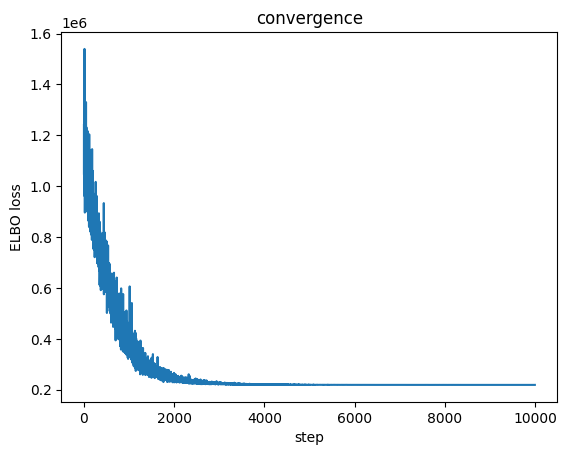

In [23]:
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

Converges well!

Access samples from the posterior

In [24]:
from pyro.infer import Predictive

predictive = Predictive(model, guide=guide, num_samples=1000)
#samples = predictive(X_stress_train[:100], X_weather_train[:100], y_train[:100])
samples = predictive(X_stress_train, X_weather_train, None)

w_samples = samples["w"].detach().numpy()     
beta_samples = samples["beta"].detach().numpy()  

print("w means:", w_samples.mean(axis=0))
print("w stds:", w_samples.std(axis=0))
print("beta means:", beta_samples.mean(axis=0))
print("beta stds:", beta_samples.std(axis=0))

w means: [[ 0.20980191  0.05380977  0.12899381 -0.87419856 -0.15130883  0.36766186
  -0.51613677  0.7610185   0.23374096  0.33744815 -0.15367368  0.22181153
   0.36474794 -0.26709634 -0.27176917  0.29220894 -0.5552602   0.99048865]]
w stds: [[0.00046574 0.00045085 0.00049462 0.00045827 0.00048955 0.00045938
  0.00051851 0.00046712 0.00047498 0.00047986 0.00048078 0.00045794
  0.00048017 0.000513   0.00050208 0.00049375 0.00049923 0.00047741]]
beta means: [[0.19780922 0.1039638  0.00766213]]
beta stds: [[0.00320937 0.00378612 0.00207693]]


This is also good to access samples but also obs bc it gioe sthrough the whole model, it is too much

In [ ]:
# # use a small subset just to get parameter samples

# # draw 1000 samples of w and beta from the guide
# predictive = Predictive(model, guide=guide, num_samples=1000)
# samples = predictive(X_stress_train[:100], X_weather_train[:100], y_train[:100])

# w_samples = samples["w"].detach()      
# beta_samples = samples["beta"].detach()  

# print("Stress weights (airport_size, concurrent, carrier):", w_samples.mean(dim=0))
# print("Stress uncertainty:", w_samples.std(dim=0))
# print("Delay weights (rain, wind, stress):", beta_samples.mean(dim=0))
# print("Delay uncertainty:", beta_samples.std(dim=0))

Plot posteriors using seaborn

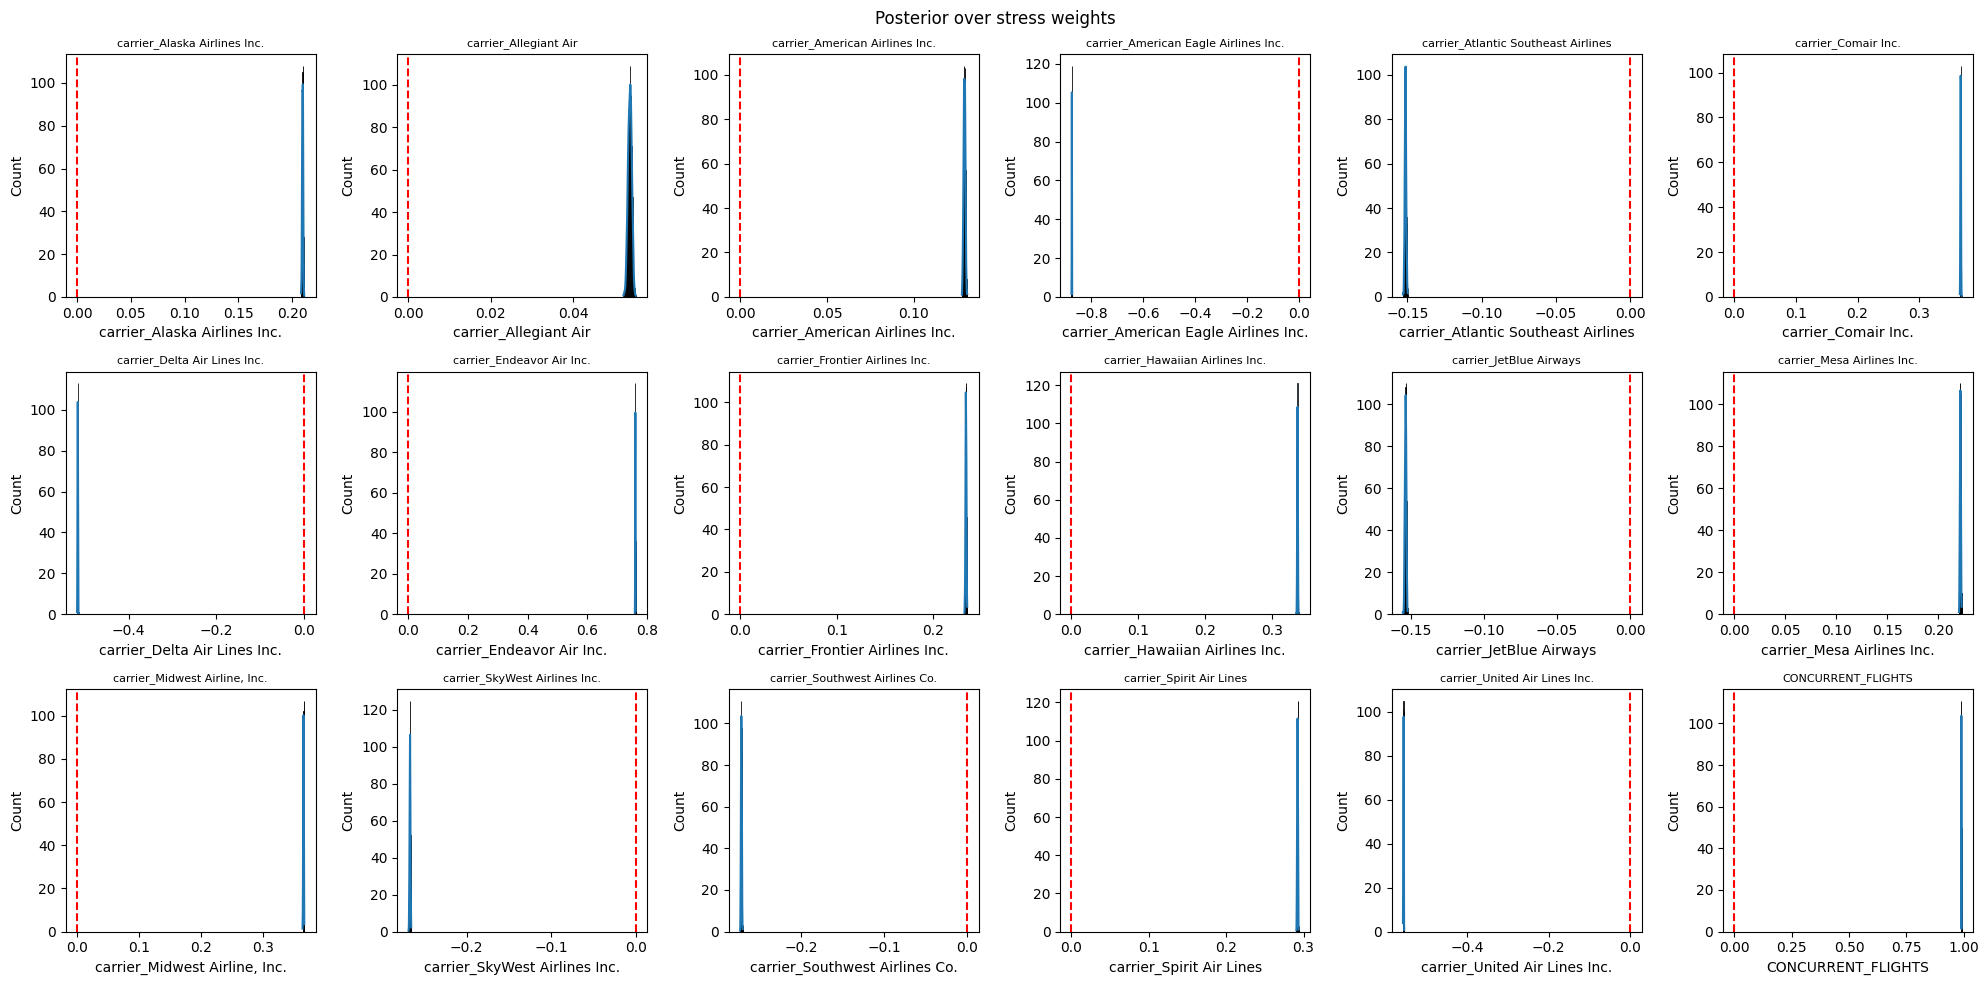

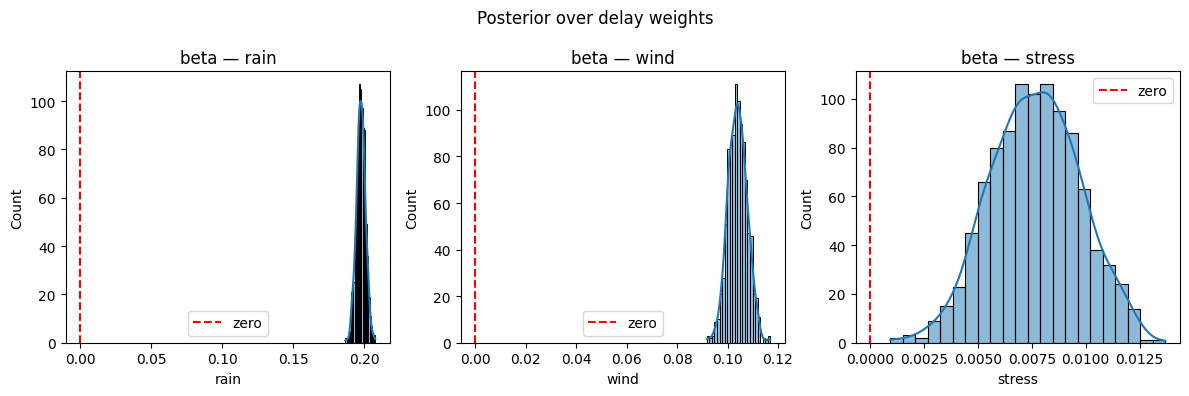

In [25]:
w_samples    = samples["w"].detach().squeeze(1).numpy()     # (1000, 18)
beta_samples = samples["beta"].detach().squeeze(1).numpy()  # (1000, 3)

# ── stress weights ──
w_df = pd.DataFrame(w_samples, columns=stress_cols)  # use actual column names

fig, axes = plt.subplots(3, 6, figsize=(20, 10))  # 18 plots — 3 rows of 6
axes = axes.flatten()
for i, col in enumerate(w_df.columns):
    sns.histplot(w_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

# ── delay weights ──
beta_df = pd.DataFrame(beta_samples, columns=["rain", "wind", "stress"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(beta_df.columns):
    sns.histplot(beta_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--", label="zero")
    axes[i].set_title(f"beta — {col}")
    axes[i].legend()
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

Posterior predictive check

For the train data, we use the parameters we learned to see if the model would predict the delay correctly

In [26]:
# get bias samples
bias_samples = samples["bias"].detach().squeeze(1).numpy()

stress_train = X_stress_train.numpy() @ w_samples.mean(axis=0)

logits_train = (beta_samples.mean(axis=0)[0] * X_weather_train.numpy()[:,0] +
                beta_samples.mean(axis=0)[1] * X_weather_train.numpy()[:,1] +
                beta_samples.mean(axis=0)[2] * stress_train +
                bias_samples.mean())  # add bias

p_train  = torch.sigmoid(torch.tensor(logits_train)).numpy()
y_fake   = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())

Real delay rate: 0.1891448
Fake delay rate: 0.18877494859477714


In [27]:
bias_samples = samples["bias"].detach().squeeze(1).numpy()
print("bias mean:", bias_samples.mean())
print("bias std:", bias_samples.std())

bias mean: -1.4749392
bias std: 0.0040404354


# 3. Testing

In [ ]:
CHUNK = 10000
p_mean_list = []
p_std_list  = []

# sample w and beta once — they are global
predictive = Predictive(model, guide=guide, num_samples=1000)
samples = predictive(X_stress_test[:100], X_weather_test[:100], None)

w_samples    = samples["w"].detach()      # (1000, 3)
beta_samples = samples["beta"].detach()   # (1000, 3)

for i in range(0, len(X_stress_test), CHUNK):
    X_s = X_stress_test[i:i+CHUNK]    # (chunk, 3)
    X_w = X_weather_test[i:i+CHUNK]   # (chunk, 2)

    stress  = X_s @ w_samples.T                          # (chunk, 1000)
    logits  = (beta_samples[:,0] * X_w[:,0:1].T +
               beta_samples[:,1] * X_w[:,1:2].T +
               beta_samples[:,2] * stress.T).T           # (chunk, 1000)

    p = torch.sigmoid(logits)                            # (chunk, 1000)
    p_mean_list.append(p.mean(dim=1))                    # (chunk,)
    p_std_list.append(p.std(dim=1))                      # (chunk,)

p_mean = torch.cat(p_mean_list)   # (N_test,)
p_std  = torch.cat(p_std_list)    # (N_test,)
y_pred = (p_mean > 0.5).float()

In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_test_np  = y_test.numpy()
y_pred_np  = y_pred.numpy()
p_mean_np  = p_mean.detach().numpy()

print("Accuracy:", accuracy_score(y_test_np, y_pred_np))
print("AUC-ROC:", roc_auc_score(y_test_np, p_mean_np))
print(classification_report(y_test_np, y_pred_np))

Accuracy: 0.6140783544004039
AUC-ROC: 0.563318985060951
              precision    recall  f1-score   support

         0.0       0.83      0.66      0.73   1578509
         1.0       0.23      0.43      0.30    368210

    accuracy                           0.61   1946719
   macro avg       0.53      0.54      0.52   1946719
weighted avg       0.72      0.61      0.65   1946719



In [33]:
import numpy as np

# bin flights by predicted probability
bins = np.linspace(0, 1, 11)
bin_indices = np.digitize(p_mean_np, bins)

for b in range(1, 11):
    mask = bin_indices == b
    if mask.sum() > 0:
        predicted = p_mean_np[mask].mean()
        actual    = y_test_np[mask].mean()
        print(f"predicted {predicted:.2f} → actual delay rate {actual:.2f}")
        

predicted 0.48 → actual delay rate 0.17
predicted 0.52 → actual delay rate 0.22
predicted 0.64 → actual delay rate 0.32
predicted 0.74 → actual delay rate 0.36
predicted 0.85 → actual delay rate 0.31
predicted 0.93 → actual delay rate 0.20


In [35]:
stress_train  = torch.tensor(X_stress, dtype=torch.float32) @ pyro.param("w_mu").detach()
logits_train  = (pyro.param("beta_mu")[0] * torch.tensor(X_weather[:,0], dtype=torch.float32) +
                 pyro.param("beta_mu")[1] * torch.tensor(X_weather[:,1], dtype=torch.float32) +
                 pyro.param("beta_mu")[2] * stress_train)
p_train       = torch.sigmoid(logits_train).detach().numpy()
y_fake        = np.random.binomial(1, p_train)

print("Real delay rate:",  y.numpy().mean())
print("Fake delay rate:",  y_fake.mean())

C:\Users\Maria\AppData\Local\Temp\ipykernel_17172\3579723779.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits_train  = (pyro.param("beta_mu")[0] * torch.tensor(X_weather[:,0], dtype=torch.float32) +
C:\Users\Maria\AppData\Local\Temp\ipykernel_17172\3579723779.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pyro.param("beta_mu")[1] * torch.tensor(X_weather[:,1], dtype=torch.float32) +


Real delay rate: 0.18914424
Fake delay rate: 0.500068576943661
